### Nomes:
#### Patrícia da Silva Costa e Valdir de Souza Carvalho Neto
**SI 241**

# Tarefa 1 — Importar e carregar os dados

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

# Carregando o dataset
base = load_wine(as_frame=True)
data = base.frame

# Mostrando o número de linhas e colunas
print(data.shape)

(178, 14)


#### a) Realize os comandos nescessários e diga quantas linhas existem na base? Quantas colunas existem?
Existem **178** linhas e **14** colunas.

# Tarefa 2 — Explorar os dados

a) Colunas:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

b) Quantidade de valores ausentes em cada coluna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                    

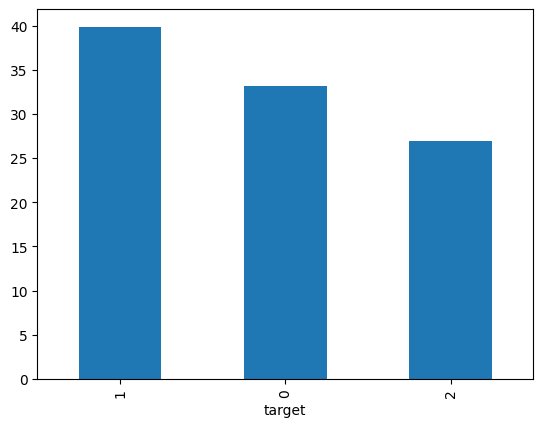

In [17]:
# a) os nomes e os tipos das colunas;
print(f"a) Colunas:\n{data.dtypes}")

# b) a quantidade de valores ausentes;
print(f"\nb) Quantidade de valores ausentes em cada coluna:\n{data.isnull().sum()}")
print(f"\nQuantidade de valores ausentes no total: {data.isnull().sum().sum()}")

# c) a quantidade de vinhos de cada variedade de uva;
print(f"\nc) Quantidade de vinhos de cada variedade de uva:")
print(data["target"].value_counts().sort_index())

# d) a proporção de cada classe.
print(f"\nd) Proporção de cada classe:")
print(round(data["target"].value_counts(normalize=True).sort_index() * 100, 2))

print(f"\nGráfico de barras com a quantidade de exemplos de cada classe:")
print(round(data["target"].value_counts(normalize=True) * 100, 2).plot(kind="bar"))

# Tarefa 3 — Escolher as entradas e a resposta

In [18]:
from sklearn.model_selection import train_test_split

features = [
"alcohol",
"malic_acid",
"ash",
"alcalinity_of_ash",
"magnesium",
"total_phenols"
]

X = data[features]
y = data["target"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42)

#### Explique, com suas palavras, qual é a função de X e qual é a função de y no treinamento. Depois separe 20% dos dados para validação usando train_test_split.
O **X** são as colunas que iremos usar para treinar o modelo e posteriomente fazer uma possível validação. O **y** é justamente a coluna que queremos prever (*alvo*), e caso seja separado uma parte de **X** para validação, também usamos parte dessa coluna para fazer a validação do modelo.

# Tarefa 4 — Criar os dois algoritmos

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

knn = Pipeline(steps=[
("padronizacao", StandardScaler()),
("modelo", KNeighborsClassifier(n_neighbors=5))])

rf = RandomForestClassifier(
n_estimators=200,
max_depth=5,
random_state=42
)

#### Descreva uma diferença entre os dois algoritmos.
O **KNN** baseia-se na proximidade geográfica entre os dados, enquanto o **RandomForestClassifier** baseia-se em regras de decisão em formato de árvore.


# Tarefa 5 — Combinar os algoritmos

In [20]:
modelo_votacao = VotingClassifier(
    estimators=[
        ('knn_pipeline', knn),
        ('random_forest', rf)
    ],
    voting='soft'
)

knn.fit(X_train, y_train)
rf.fit(X_train, y_train)
modelo_votacao.fit(X_train, y_train)

VotingClassifier(estimators=[('knn_pipeline',
                              Pipeline(steps=[('padronizacao',
                                               StandardScaler()),
                                              ('modelo',
                                               KNeighborsClassifier())])),
                             ('random_forest',
                              RandomForestClassifier(max_depth=5,
                                                     n_estimators=200,
                                                     random_state=42))],
                 voting='soft')

# Tarefa 6 — Avaliar e comparar

In [21]:
from sklearn.metrics import accuracy_score

previsao_knn = knn.predict(X_val)
previsao_rf = rf.predict(X_val)
previsao_mv = modelo_votacao.predict(X_val)

acuracia_knn = accuracy_score(y_val, previsao_knn)
acuracia_rf = accuracy_score(y_val, previsao_rf)
acuracia_mv = accuracy_score(y_val, previsao_mv)

dados_resultados = {
    'Modelo': ['KNN', 'Floresta Aleatória', 'Modelo combinado'],
    'Acurácia (%)': [acuracia_knn*100, acuracia_rf*100, acuracia_mv*100]
}

tabela_acuracia = pd.DataFrame(dados_resultados)
tabela_acuracia.style.format({'Acurácia (%)': '{:.2f}%'})



,Modelo,Acurácia (%)
0,KNN,91.67%
1,Floresta Aleatória,97.22%
2,Modelo combinado,91.67%


#### a) Qual modelo obteve a maior acurácia?
O modelo que obteve a maior acurácia foi a **Floresta Aleatória**.

#### b) A combinação superou os dois modelos individuais?
Não, a combinação teve acurácia igual ao modelo KNN.

#### c) A diferença entre os resultados foi grande ou pequena?
A diferença foi pequena, sendo de 5,55% do modelo **Floresta Aleatória** para os demais (**KNN** e **Modelo combinado**).


# Tarefa 7 — Analisar a matriz de confusão

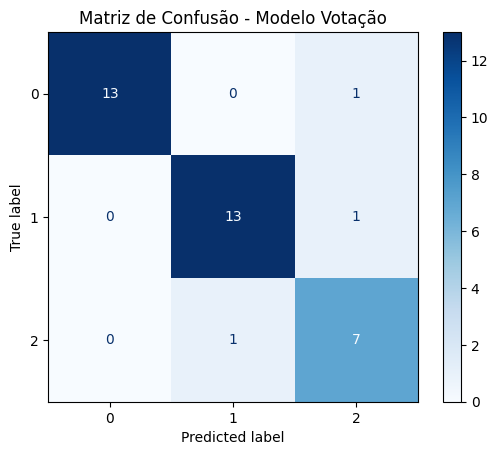

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 2. Plotar usando os arrays de dados
ConfusionMatrixDisplay.from_predictions(
    y_val,
    previsao_mv,
    cmap=plt.cm.Blues
)

plt.title("Matriz de Confusão - Modelo Votação")
plt.show()

#### Total de acertos: 
33


#### Total de erros:
3


#### Exemplos da variedade 0 classificados como outra variedade:
Teve 1 erro que era da variedade 0 e foi classificada como variedade 2.


#### Exemplos da variedade 1 classificados como outra variedade:
Teve 1 erro que era da variedade 1 e foi classificada como variedade 2.


#### Exemplos da variedade 2 classificados como outra variedade:
Teve 1 erro que era da variedade 2 e foi classificada como variedade 1.


#### Explique por que a matriz de confusão fornece informações que não aparecem quando observamos somente a acurácia.
A acurácia apenas calcula a poecentagem do total de previsões que o modelo acertou, já a matriz de confusão mostra exatamente onde e como o modelo errou.

# Conclusão

O melhor modelo avaliado isoladamente foi a **Floresta Aleatória**, que apresentou a maior capacidade de generalização e acurácia (**97,22%**).

**Vantagem de utilizar a combinação (Voting):** A principal vantagem teórica é o aumento da robustez e a diminuição da variância. Como o KNN e a Floresta Aleatória tomam decisões de formas fundamentalmente diferentes (distância vs. regras de corte), combiná-los pode reduzir vieses individuais e criar um modelo que generaliza melhor diante de dados ruidosos não vistos, evitando o overfitting.

**Desvantagem de utilizar a combinação (Voting):** Se um dos modelos tiver um desempenho significativamente inferior, ele atua como uma âncora, prejudicando a performance do modelo superior. Foi exatamente o que ocorreu neste experimento, o desempenho inferior do KNN "puxou para baixo" as predições do Voting Classifier, anulando o excelente resultado que a Floresta Aleatória havia alcançado sozinha. Além disso, a combinação exige maior tempo de processamento computacional e resulta na perda de explicabilidade (interpretabilidade) do modelo final.